<a href="https://colab.research.google.com/github/GabrielvanderSchmidt/Low-Rank-Transformers/blob/main/experiments/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
!nvidia-smi

In [55]:
import pandas as pd
import numpy as np
import torch
from transformers import BertModel, ViTModel
import os

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

## Investigate patterns in BERT weights and SVD decompositions

In [61]:
# @title Get BERT weights and SVD decompositions


def module_name_parser(name):
    """Assuming a BERT-attention-style naming, e. g.:
    encoder.layer.0.attention.self.query"""
    _, _, layer, _, _, vector = name.split(".")
    return layer, vector

def get_svd(name, module):
    if any([target in name for target in ["query", "key", "value"]]):
        layer, vector = module_name_parser(name)
        weights[f"{layer}-{vector}"] = module.weight.to(torch.float32).cpu().detach().flatten().numpy()
        _, s, _ = torch.svd(module.weight.to(torch.float32))
        s_values[f"{layer}-{vector}"] = s.cpu().detach().numpy()

def recursive_get_svd(obj, attr, value):
    attr = attr.split('.', 1)
    if not len(attr) == 1:
        recursive_get_svd(getattr(obj, attr[0]), attr[1], value)

# Since I am only looking into the attention layers, the unexpected task-specific
# pretraining heads are not a problem
model = BertModel.from_pretrained("bert-base-cased")
s_values = pd.DataFrame()
weights = pd.DataFrame()
for name, module in tuple(model.named_modules()):
    if name:
        recursive_get_svd(model, name, get_svd(name, module))
s_values

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,0-query,0-key,0-value,1-query,1-key,1-value,2-query,2-key,2-value,3-query,...,8-value,9-query,9-key,9-value,10-query,10-key,10-value,11-query,11-key,11-value
0,4.592468,4.717544,2.016027,4.362650,5.635216,2.279785,5.384905,5.818350,2.472238,4.773739,...,2.497493,4.228126,5.497530,2.376366,4.781015,4.545308,2.712647,5.594323,5.243222,3.156863
1,4.318059,3.839530,1.841177,4.330913,5.133987,2.256251,5.295013,5.194567,2.270573,4.665798,...,2.420491,3.659902,4.518421,2.280751,4.284163,3.968716,2.273512,4.486386,4.302880,2.656658
2,3.790214,3.748142,1.794599,4.248749,5.053680,2.200786,4.743956,5.035920,2.221798,4.473962,...,2.332186,3.545272,4.176682,2.221227,3.501133,3.496038,2.154753,4.385613,3.740912,2.442294
3,3.611653,3.421291,1.768321,4.216981,4.904458,2.178458,4.661881,4.941666,2.183042,4.297661,...,2.282443,3.525191,3.888891,2.204925,3.332887,3.471995,2.000749,3.728076,3.479464,2.435384
4,3.511364,3.245819,1.758374,4.196108,4.857185,2.140238,4.592923,4.701231,2.159916,3.756257,...,2.261996,3.502638,3.735543,2.166445,3.302031,3.373354,1.942317,3.530322,3.375220,2.417363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,0.005929,0.004915,0.004472,0.004235,0.004322,0.004720,0.006406,0.006341,0.005128,0.005717,...,0.005271,0.005856,0.004576,0.004986,0.006201,0.006085,0.006135,0.005274,0.006186,0.004071
764,0.003339,0.003719,0.003228,0.001994,0.003831,0.003240,0.005153,0.004487,0.004524,0.004486,...,0.004900,0.005530,0.004098,0.004210,0.005974,0.005322,0.005749,0.002883,0.005185,0.003987
765,0.002690,0.003131,0.002981,0.001250,0.003045,0.002841,0.003548,0.002905,0.002606,0.003959,...,0.003310,0.003470,0.003399,0.002538,0.003111,0.003951,0.003664,0.001816,0.003396,0.001746
766,0.002031,0.001037,0.001558,0.000440,0.001592,0.001320,0.002344,0.002046,0.001799,0.001686,...,0.000874,0.001583,0.001964,0.001727,0.002897,0.002991,0.001751,0.001022,0.002038,0.001431


In [ ]:
# @title Visualize per-layer weight distribution


weights_melted = weights.melt(var_name='layer', value_name='weight_value')

fig = px.density_heatmap(weights_melted,
                         x='layer',
                         y='weight_value',
                         title="Per-layer Weight Distribution Heatmap",
                         labels={
                             "layer": "BERT Layers",
                             "weight_value": "Weight Value"
                         })
fig.update_xaxes(tickangle=45)
# fig.show()
# Interactive output is too large to keep on the notebook. Below is the PNG export of the result

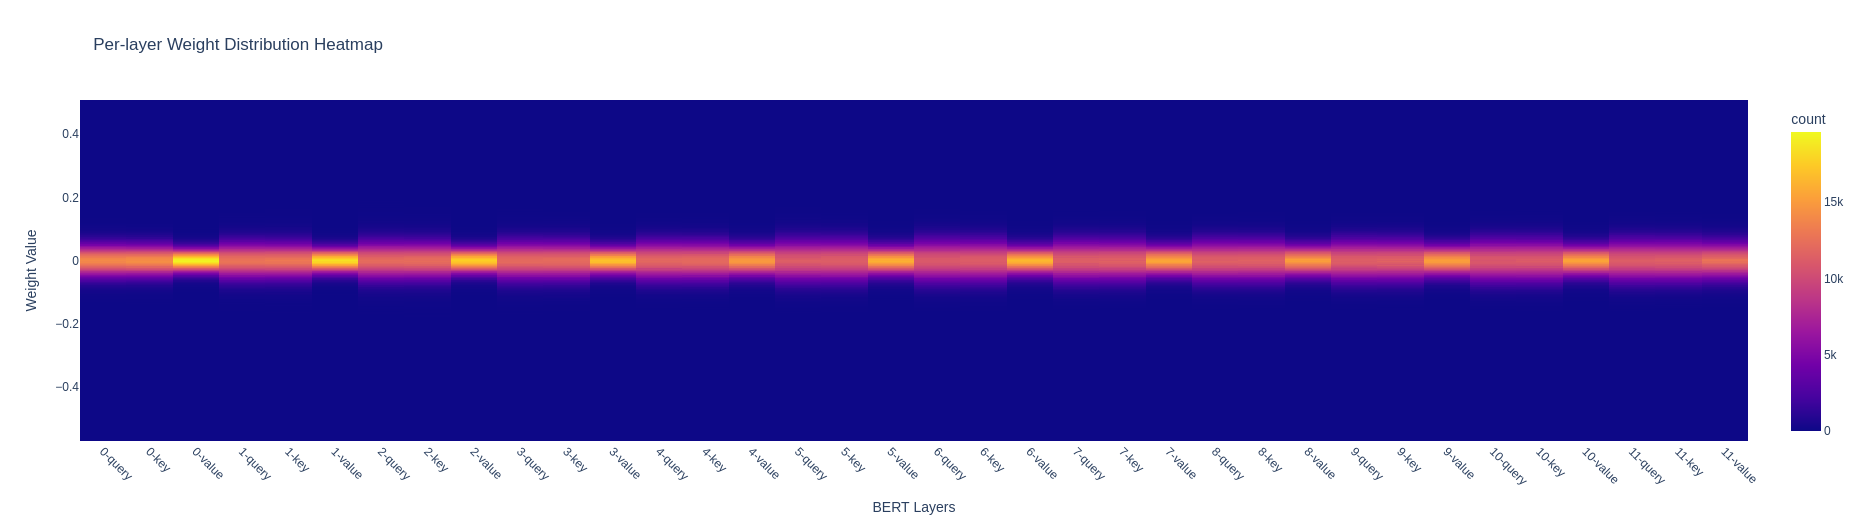

In [ ]:
# @title Get heatmap of raw $\Sigma$ values


fig = px.imshow(s_values.T,
                labels={"x" : "Layer Depth",
                        "y" : "Layer"},
                title="Per-layer S values (BERT)", # LaTeX formating breks title display
                )
fig.update_yaxes(dtick=1)
fig.show()

In [ ]:
# @title Calculate effect of $\beta$ on rank


data = {
    "beta" : [],
    "rank" : [],
    "layer" : [],
    "component" : [],
    }

betas = list(np.linspace(0, 1, 101))
for layer in s_values.columns:
    i, component = layer.split("-")
    ranks = [np.count_nonzero(s_values[layer] > np.max(s_values[layer]) * beta) for beta in betas]
    data["beta"].extend(betas)
    data["rank"].extend(ranks)
    data["layer"].extend([i] * len(betas))
    data["component"].extend([component] * len(betas))

ranks_over_beta = pd.DataFrame(data)

In [ ]:
# @title Display effect of $\beta$ on rank (per component)


fig = px.line(
    ranks_over_beta,
    x="beta",
    y="rank",
    color="component",
    line_dash="layer",
    title=r"Effect of beta on rank (BERT)"
)
fig.show()

In [ ]:
# @title Display effect of $\beta$ on rank (per layer)


fig = px.line(
    ranks_over_beta,
    x="beta",
    y="rank",
    color="layer",
    line_dash="component",
    title=r"Effect of beta on rank (BERT)"
)
fig.show()

## Investigate patterns in ViT weights and SVD decompositions

In [63]:
# @title Get ViT weights and SVD decompositions


def module_name_parser(name):
    """Assuming a ViT-attention-style naming, e. g.:
    encoder.layer.0.attention.attention.query"""
    _, _, layer, _, _, vector = name.split(".")
    return layer, vector

def get_svd(name, module):
    if any([target in name for target in ["query", "key", "value"]]):
        layer, vector = module_name_parser(name)
        weights[f"{layer}-{vector}"] = module.weight.to(torch.float32).cpu().detach().flatten().numpy()
        _, s, _ = torch.svd(module.weight.to(torch.float32))
        s_values[f"{layer}-{vector}"] = s.cpu().detach().numpy()

def recursive_get_svd(obj, attr, value):
    attr = attr.split('.', 1)
    if not len(attr) == 1:
        recursive_get_svd(getattr(obj, attr[0]), attr[1], value)

# Since I am only looking into the attention layers, the unexpected task-specific
# pretraining heads are not a problem
model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k", torch_dtype=torch.float16)
s_values = pd.DataFrame()
weights = pd.DataFrame()
for name, module in tuple(model.named_modules()):
    if name:
        recursive_get_svd(model, name, get_svd(name, module))
s_values

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

,0-query,0-key,0-value,1-query,1-key,1-value,2-query,2-key,2-value,3-query,...,8-value,9-query,9-key,9-value,10-query,10-key,10-value,11-query,11-key,11-value
0,21.185942,27.206459,6.422772,13.649027,15.151893,5.197780,9.853331,11.892754,7.000762,8.395294,...,5.572425,8.099009,8.443003,5.736108,8.963618,8.330530,6.868063,7.464956,13.141583,11.271502
1,20.622126,20.562738,4.720056,13.101475,14.756716,5.073423,9.728158,11.184510,6.106983,8.200747,...,5.508151,7.553866,6.131022,5.518293,6.932741,6.241054,5.414619,5.244722,4.484729,5.354236
2,20.335024,19.886070,4.698986,12.801453,14.053365,4.986546,9.559518,10.944734,5.979177,8.044665,...,5.407171,6.953323,5.999969,5.422587,5.949891,5.529721,5.261653,4.330134,4.277057,5.344086
3,19.354759,19.749172,4.588879,12.761304,13.550841,4.873830,9.370101,10.513989,5.722816,7.882654,...,5.369278,6.519848,5.617971,5.372014,5.574920,5.029037,5.229552,4.126118,4.124728,5.294908
4,19.185530,18.902090,4.491859,12.567884,13.194046,4.787230,9.325835,10.312857,5.634542,7.806078,...,5.334260,6.245225,5.302495,5.280715,5.398740,4.920259,5.178302,4.048399,3.976768,5.283070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,0.001031,0.001086,0.003403,0.001611,0.001736,0.006383,0.003523,0.003286,0.006004,0.004097,...,0.016504,0.012108,0.013962,0.012584,0.013171,0.013923,0.019225,0.012233,0.010389,0.044253
764,0.000783,0.000805,0.002290,0.001449,0.001091,0.004963,0.002698,0.002429,0.004815,0.003510,...,0.013787,0.008936,0.009849,0.011466,0.011250,0.012748,0.016667,0.008318,0.009132,0.035343
765,0.000463,0.000431,0.001379,0.000750,0.000755,0.002552,0.001910,0.001528,0.003788,0.002424,...,0.009782,0.008420,0.008158,0.006014,0.007547,0.009465,0.009450,0.004906,0.006920,0.010577
766,0.000262,0.000329,0.000564,0.000585,0.000381,0.001890,0.001313,0.000371,0.002918,0.001674,...,0.007295,0.003657,0.004749,0.004038,0.003330,0.007791,0.006200,0.003449,0.004183,0.005107


In [ ]:
# @title Visualize per-layer weight distribution


weights_melted = weights.melt(var_name='layer', value_name='weight_value')

fig = px.density_heatmap(weights_melted,
                         x='layer',
                         y='weight_value',
                         title="Per-layer Weight Distribution Heatmap",
                         labels={
                             "layer": "ViT Layers",
                             "weight_value": "Weight Value"
                         })
fig.update_xaxes(tickangle=45)
# fig.show()
# Interactive output is too large to keep on the notebook. Below is the PNG export of the result

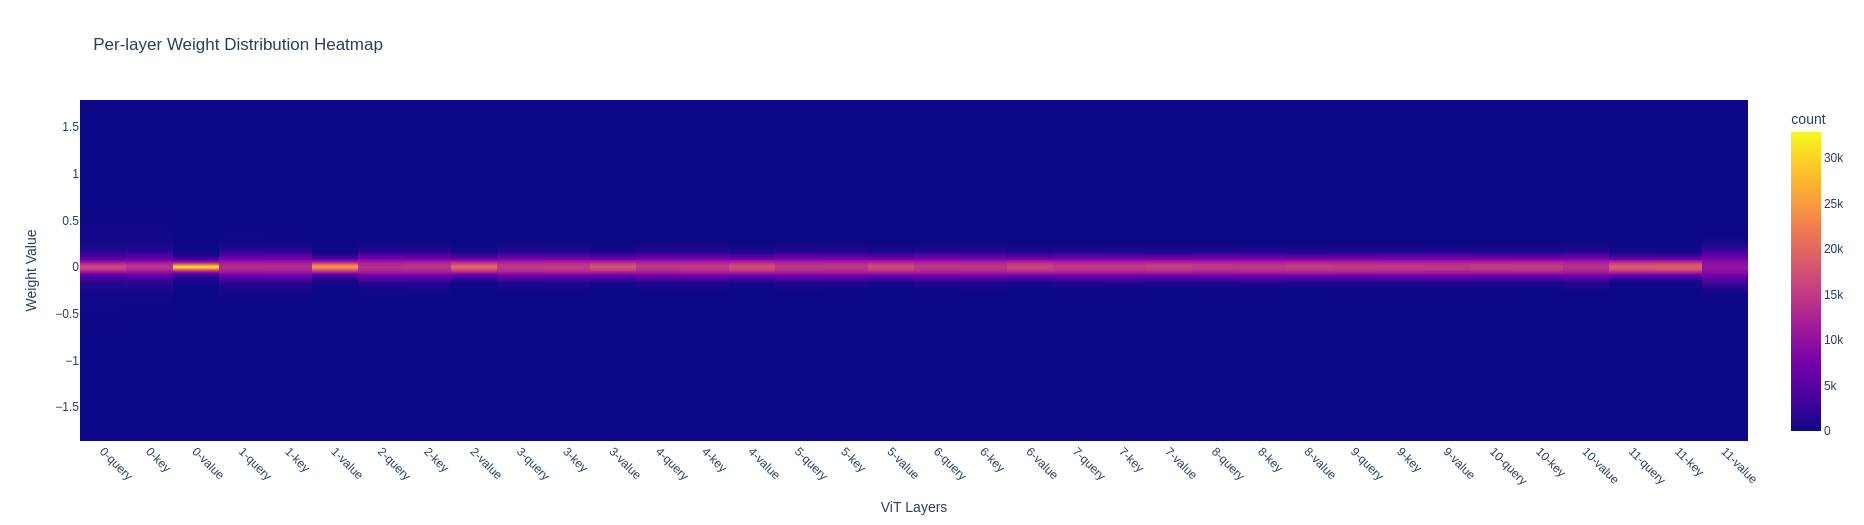

In [64]:
# @title Get heatmap of raw $\Sigma$ values


fig = px.imshow(s_values.T,
                labels={"x" : "Layer Depth",
                        "y" : "Layer"},
                title="Per-layer S values (ViT)", # LaTeX formating breks title display
                )
fig.update_yaxes(dtick=1)
fig.show()

In [65]:
# @title Calculate effect of $\beta$ on rank


data = {
    "beta" : [],
    "rank" : [],
    "layer" : [],
    "component" : [],
    }

betas = list(np.linspace(0, 1, 101))
for layer in s_values.columns:
    i, component = layer.split("-")
    ranks = [np.count_nonzero(s_values[layer] > np.max(s_values[layer]) * beta) for beta in betas]
    data["beta"].extend(betas)
    data["rank"].extend(ranks)
    data["layer"].extend([i] * len(betas))
    data["component"].extend([component] * len(betas))

ranks_over_beta = pd.DataFrame(data)

In [66]:
# @title Display effect of $\beta$ on rank (per component)


fig = px.line(
    ranks_over_beta,
    x="beta",
    y="rank",
    color="component",
    line_dash="layer",
    title=r"Effect of beta on rank (ViT)"
)
fig.show()

In [67]:
# @title Display effect of $\beta$ on rank (per layer)


fig = px.line(
    ranks_over_beta,
    x="beta",
    y="rank",
    color="layer",
    line_dash="component",
    title=r"Effect of beta on rank (ViT)"
)
fig.show()